# Multi class classification
DA SISTEMARE !!!!!!!!!!!! <br>
L'obbiettivo di questo notebook è quello di crare un modello di regressione predittiva, il quale grazie a i vari rating tende a stimare il prezzo di un smartphone.<br>
In questo notebook non si approfondisce la pulizia e la struttura del dataset, questo perché è presente nel notebook "main".
Inizialmente abbiamo anche pensato di fare un modello che dati i vari rating e l'età dell'utente, andava a consigliare il modello più adatto, il problema è che i dati erano troppo deboli e il modello andava a caso (rating success del 30% e loss di 1.5)

### Import dataset

In [1]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
from tensorflow import keras
import tensorflow as tf
import seaborn as sns
import pandas as pd
import numpy as np

df = pd.read_csv("./data/Mobile Reviews Sentiment.csv")

## Predizione brand telefono in base all'età, alla nazionalità e al rating

### Pulizia dataset
Alla fine di questo processo avremo a disposizione solamente le colonne: age; battery_life_rating; camera_rating; performance_rating; design_rating; display_rating
In più proviamo anche a creare una features di rapporto prezzo-qualità, la quale risulterà più determinante ma non abbastanza per fare il modello. 

In [2]:
df["ratio"] = df['price_usd'] / df['rating']
features = ["country", "age",  "ratio", "rating"]
colonne_da_tenere = features + ["brand"]
df_clean = df[colonne_da_tenere].copy()

class_model = df_clean['brand'].unique()

mapping = {modello: idx for idx, modello in enumerate(class_model)}
df_clean['brand_idx'] = df_clean['brand'].map(mapping)
df_clean = df_clean.drop('brand', axis=1)

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    50000 non-null  object 
 1   age        50000 non-null  int64  
 2   ratio      50000 non-null  float64
 3   rating     50000 non-null  int64  
 4   brand_idx  50000 non-null  int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 1.9+ MB


#### Tabella

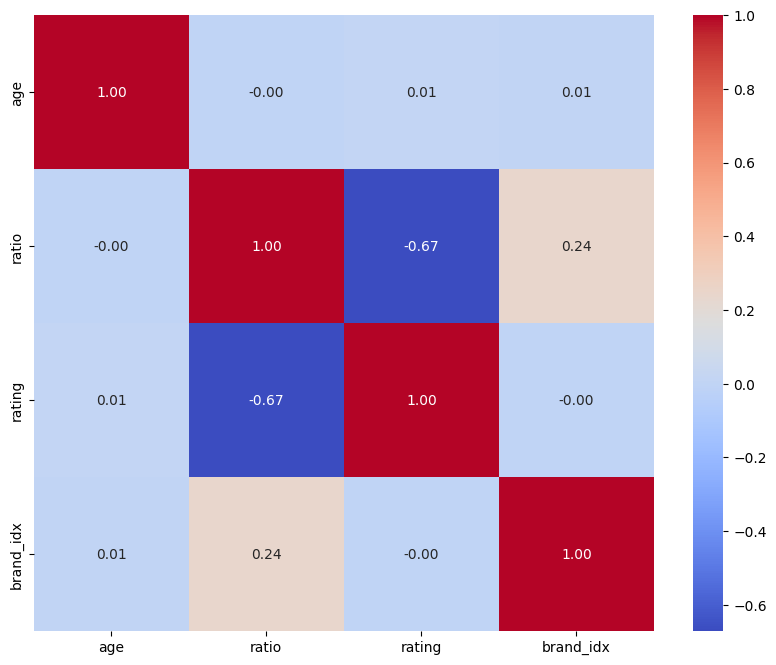

In [3]:
corr_matrix = df_clean.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

### Scaling

In [4]:
X = df_clean[features]
y = df_clean['brand_idx']

pipeline = ColumnTransformer([
    ("num", StandardScaler(), features[1:]),
    ("cat", OneHotEncoder(drop = "first"), features[:1]),
])
X = pipeline.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(40000, 10) (10000, 10)
(40000,) (10000,)


### Rete neurale

In [5]:
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.Input(shape=(10,)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(22, activation='softmax')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.004),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 22)             │           726 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,846 (85.34 KB)

 Trainable params: 21,846 (85.34 KB)

 Non-trainable params: 0 (0.00 B)

### Allenamento

In [60]:
history = model.fit(X_train, y_train, epochs=30, validation_data=(X_test, y_test))

Epoch 1/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.3007 - loss: 1.5429 - val_accuracy: 0.2858 - val_loss: 1.4972
Epoch 2/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3146 - loss: 1.4562 - val_accuracy: 0.2895 - val_loss: 1.4535
Epoch 3/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3183 - loss: 1.4383 - val_accuracy: 0.2955 - val_loss: 1.4392
Epoch 4/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3244 - loss: 1.4262 - val_accuracy: 0.3023 - val_loss: 1.4420
Epoch 5/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3238 - loss: 1.4209 - val_accuracy: 0.3047 - val_loss: 1.4192
Epoch 6/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3279 - loss: 1.4170 - val_accuracy: 0.3063 - val_loss: 1.4304
Epoch 7/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3281 - loss: 1.4114 - val_accuracy: 0.3103 - val_loss: 1.4111
Epoch 8/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3263 - loss: 1.4090 - 

Analisi dell'allenamento

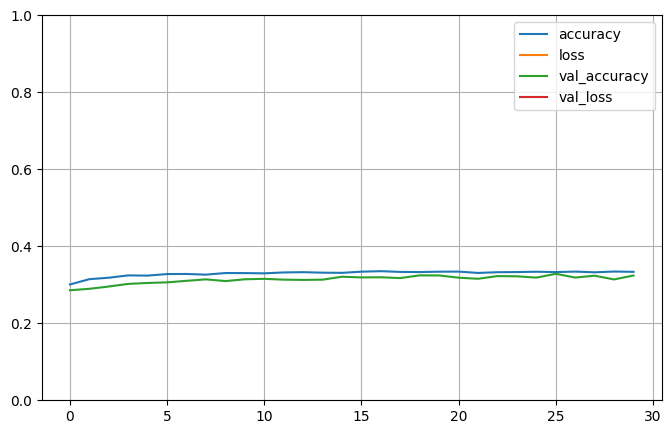

In [61]:
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

## Predizione prezzo

### Pulizia dataset

In [6]:
features = ["battery_life_rating", "camera_rating", "performance_rating", "design_rating", "display_rating", "brand"]
colonne_da_tenere = features + ["price_usd"]
df_clean = df[colonne_da_tenere].copy()

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   battery_life_rating  50000 non-null  int64  
 1   camera_rating        50000 non-null  int64  
 2   performance_rating   50000 non-null  int64  
 3   design_rating        50000 non-null  int64  
 4   display_rating       50000 non-null  int64  
 5   brand                50000 non-null  object 
 6   price_usd            50000 non-null  float64
dtypes: float64(1), int64(5), object(1)
memory usage: 2.7+ MB


### Scaling

In [7]:
X = df_clean[features]
y = df_clean['price_usd']
pipeline = ColumnTransformer([
    ("num", StandardScaler(), features[:-1]),
    ("cat", OneHotEncoder(drop = "first"), ["brand"]),
])
X = pipeline.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(40000, 11) (10000, 11)
(40000,) (10000,)


### Rete neurale

In [8]:
model = keras.models.Sequential([
    keras.layers.Dense(30, activation="relu", input_shape=X_train.shape[1:]),
    keras.layers.Dense(15, activation="relu"),
    keras.layers.Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()

C:\Users\julic\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 30)             │           360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 15)             │           465 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 841 (3.29 KB)

 Trainable params: 841 (3.29 KB)

 Non-trainable params: 0 (0.00 B)

### Addrestramento

In [65]:
history = model.fit(X_train, y_train, epochs=20, validation_data=(X_test, y_test))

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 240380.9062 - mae: 382.3955 - val_loss: 97439.4062 - val_mae: 238.3051
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 81975.9453 - mae: 219.4426 - val_loss: 67341.0391 - val_mae: 201.0854
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 54691.5664 - mae: 184.6806 - val_loss: 44478.2500 - val_mae: 171.2318
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 40338.4609 - mae: 165.9984 - val_loss: 38579.5117 - val_mae: 163.7221
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 38287.3555 - mae: 163.3201 - val_loss: 38225.0078 - val_mae: 163.2312
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 38186.0039 - mae: 163.1663 - val_loss: 38189.4766 - val_mae: 163.1677
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 38166.2578 - mae: 163.1261 - val_loss: 38174.3359 - val_mae: 163.1331
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 38154.6875 - 

Analisi allenamento

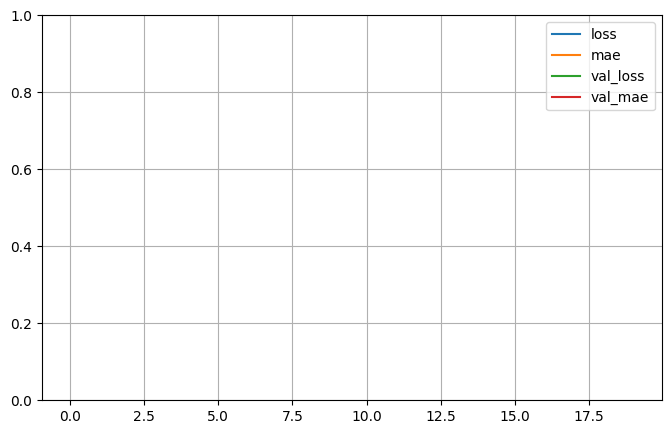

In [66]:
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()